In [5]:
# Ensure dependencies are installed
%pip install pandas openpyxl matplotlib scikit-learn seaborn matplotlib-venn

from google.colab import drive
drive.mount('/content/drive')

# Import required libraries
import numpy as np
import pandas as pd
from scipy.stats import zscore, chi2
from sklearn.covariance import EmpiricalCovariance
from sklearn.cluster import DBSCAN

# Set up file paths
drive_dir = r'/content/drive/My Drive'
file_path = os.path.join(drive_dir, 'Regression.xlsx')

# Ensure correct column names
factor_output_df = pd.read_excel(file_path, sheet_name="FactorOutput")
factor_columns = ['Alpha (annualisiert)', 'Value/Growth', 'Small/Large', 'Momentum', 'Volatility']  # Adjust names
factor_output_df = factor_output_df[factor_columns]

# Z-Score Outlier Detection
z_score_threshold = 2.5
z_scores = factor_output_df.apply(zscore)
factor_output_df['Z_Score_Outlier'] = (np.abs(z_scores) > z_score_threshold).any(axis=1)

# Mahalanobis Distance Outlier Detection
cov_model = EmpiricalCovariance().fit(factor_output_df)
mahalanobis_distances = cov_model.mahalanobis(factor_output_df)
factor_output_df['Mahalanobis_Distance'] = mahalanobis_distances
mahalanobis_threshold = chi2.ppf(0.975, df=len(factor_columns))
factor_output_df['Mahalanobis_Outlier'] = mahalanobis_distances > mahalanobis_threshold

# DBSCAN Outlier Detection
dbscan = DBSCAN(eps=0.5, min_samples=5)
factor_output_df['Cluster'] = dbscan.fit_predict(factor_output_df)
factor_output_df['Cluster_Outlier'] = factor_output_df['Cluster'] == -1

# Combine Outliers
factor_output_df['Combined_Outlier'] = factor_output_df[['Z_Score_Outlier', 'Mahalanobis_Outlier', 'Cluster_Outlier']].any(axis=1)

# Save results
output_path = "factor_outliers_detected.xlsx"
with pd.ExcelWriter(output_path) as writer:
    factor_output_df.to_excel(writer, sheet_name="FactorOutput_Outliers", index=False)

print(f"Outlier analysis results saved to {output_path}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Outlier analysis results saved to factor_outliers_detected.xlsx


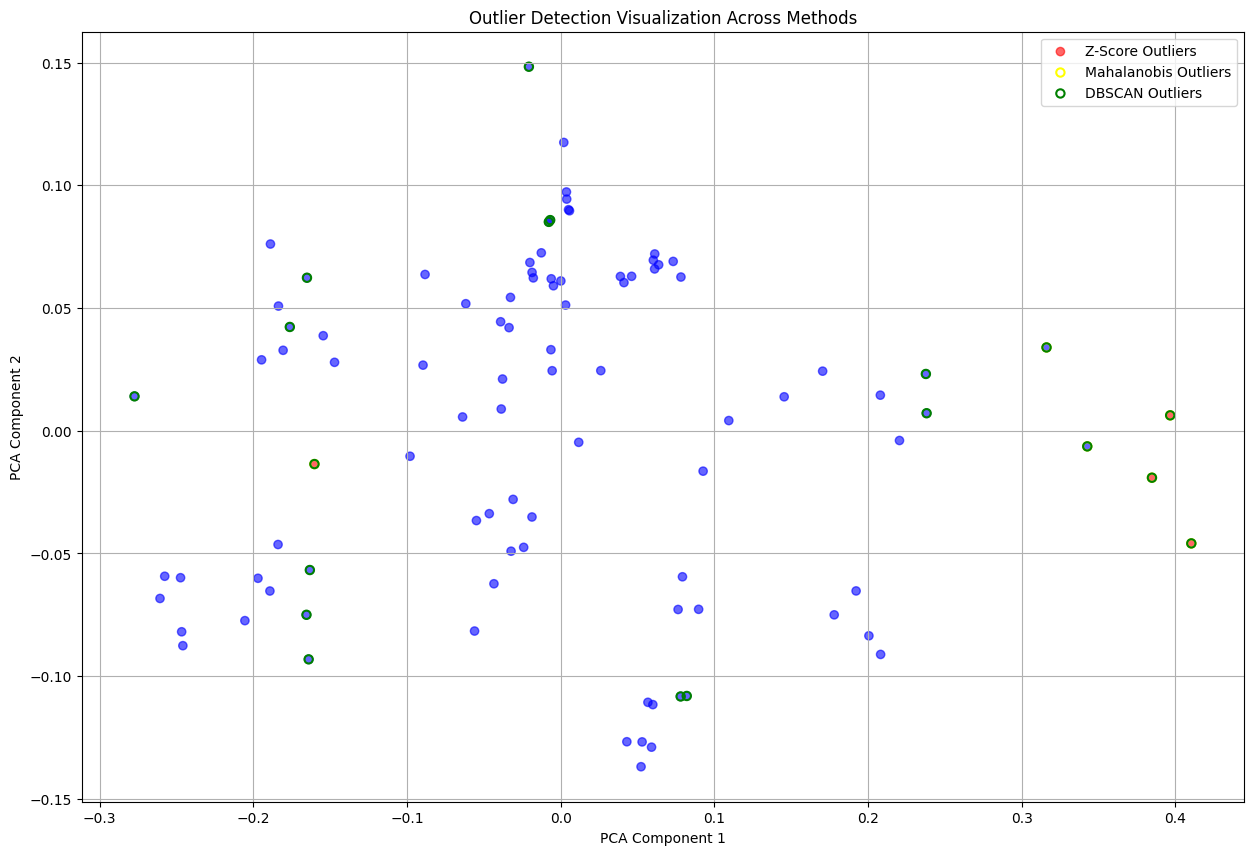

In [6]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Ensure numeric data for PCA
numeric_data = factor_output_df[factor_columns]

# Apply PCA to reduce data to 2D for visualization
pca = PCA(n_components=2)
pca_features = pca.fit_transform(numeric_data)

# Visualize the outliers detected by different methods
plt.figure(figsize=(15, 10))

# Plot Z-Score-based outliers
plt.scatter(
    pca_features[:, 0],
    pca_features[:, 1],
    c=factor_output_df['Z_Score_Outlier'].map({True: 'red', False: 'blue'}),
    label='Z-Score Outliers',
    alpha=0.6
)

# Overlay Mahalanobis outliers
plt.scatter(
    pca_features[factor_output_df['Mahalanobis_Outlier'], 0],
    pca_features[factor_output_df['Mahalanobis_Outlier'], 1],
    edgecolors='yellow',
    facecolors='none',
    label='Mahalanobis Outliers',
    linewidths=1.5
)

# Overlay DBSCAN-based outliers
plt.scatter(
    pca_features[factor_output_df['Cluster_Outlier'], 0],
    pca_features[factor_output_df['Cluster_Outlier'], 1],
    edgecolors='green',
    facecolors='none',
    label='DBSCAN Outliers',
    linewidths=1.5
)

plt.title('Outlier Detection Visualization Across Methods')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.grid()
plt.show()

In [7]:
outliers = factor_output_df[factor_output_df['Combined_Outlier']]
print("Summary Statistics for Outliers:")
print(outliers.describe())

print("\nSummary Statistics for Normal Data:")
print(factor_output_df[~factor_output_df['Combined_Outlier']].describe())


Summary Statistics for Outliers:
       Alpha (annualisiert)  Value/Growth  Small/Large   Momentum  Volatility  \
count             19.000000     19.000000    19.000000  19.000000   19.000000   
mean               0.025228      0.008588     0.019546   0.082211    0.024575   
std                0.018918      0.228674     0.076783   0.069733    0.033981   
min               -0.019329     -0.287256    -0.123684  -0.094710   -0.034707   
25%                0.014024     -0.206464    -0.029274   0.026766    0.002586   
50%                0.025236     -0.068165     0.039928   0.117718    0.025762   
75%                0.040179      0.224140     0.075638   0.133713    0.041883   
max                0.053273      0.352366     0.129614   0.161961    0.095116   

       Mahalanobis_Distance  Cluster  
count             19.000000     19.0  
mean              14.403091     -1.0  
std                9.077500      0.0  
min                7.171503     -1.0  
25%                8.292149     -1.0  
50%

In [8]:
factor_output_df['Outlier_Method_Count'] = (
    factor_output_df[['Z_Score_Outlier', 'Mahalanobis_Outlier', 'Cluster_Outlier']]
    .sum(axis=1)
)
# Outliers detected by multiple methods
consistent_outliers = factor_output_df[factor_output_df['Outlier_Method_Count'] > 1]
print("Outliers flagged by multiple methods:")
print(consistent_outliers)

Outliers flagged by multiple methods:
    Alpha (annualisiert)  Value/Growth  Small/Large  Momentum  Volatility  \
0               0.022659      0.352366    -0.006314  0.158534    0.025762   
1               0.025236      0.288853     0.037820  0.136430    0.037872   
2               0.030670      0.336041     0.035244  0.130996    0.039238   
3               0.030171      0.346278     0.062321  0.138121    0.043146   
4               0.023034      0.264381     0.083585  0.127065    0.040620   
19              0.022798     -0.206141    -0.008527  0.024959    0.095116   

    Z_Score_Outlier  Mahalanobis_Distance  Mahalanobis_Outlier  Cluster  \
0              True             25.725522                 True       -1   
1             False             17.490889                 True       -1   
2              True             25.314310                 True       -1   
3              True             26.384364                 True       -1   
4             False             20.536082      

In [9]:
from sklearn.linear_model import LinearRegression

# Example: Use all features to predict one target feature
target = 'Momentum'  # Replace with a target feature
predictors = [col for col in factor_columns if col != target]

model = LinearRegression()
model.fit(factor_output_df[predictors], factor_output_df[target])
predictions = model.predict(factor_output_df[predictors])

# Calculate residuals
factor_output_df['Residuals'] = factor_output_df[target] - predictions
factor_output_df['Residual_Outlier'] = np.abs(factor_output_df['Residuals']) > factor_output_df['Residuals'].std()

# Display residual outliers
print(factor_output_df[factor_output_df['Residual_Outlier']])

    Alpha (annualisiert)  Value/Growth  Small/Large  Momentum  Volatility  \
0               0.022659      0.352366    -0.006314  0.158534    0.025762   
1               0.025236      0.288853     0.037820  0.136430    0.037872   
2               0.030670      0.336041     0.035244  0.130996    0.039238   
3               0.030171      0.346278     0.062321  0.138121    0.043146   
4               0.023034      0.264381     0.083585  0.127065    0.040620   
5               0.020049      0.183899     0.042823  0.117718    0.031439   
6               0.019782      0.116939     0.057770  0.102775    0.019083   
16              0.041460     -0.204252    -0.086889  0.006454    0.067219   
17              0.042545     -0.206895    -0.067882  0.009332    0.061611   
23              0.030013     -0.225606     0.064486 -0.024519    0.010298   
24              0.025244     -0.287256     0.071012 -0.094710    0.008504   
25              0.031566     -0.253275    -0.037483 -0.096207    0.023005   